# Chapter 12 — Radiation, Thermodynamics, and Convection

Chapter 11 left us with a large but still local description: at
every depth and every sampled frequency, we know how strongly
matter absorbs and scatters. A stellar atmosphere needs smaller,
structural answers. How much energy crosses each layer? How much
upward support does radiation provide? Which layers are unstable
to buoyant motion?

This chapter performs that compression. It follows radiation
through all 30,000 frequencies, reduces the result to a handful of
depth-dependent columns, probes the material response to small
changes in temperature and pressure, and finally estimates the
flux that convection can carry.

The opening and closing reductions execute the actual 80-layer,
30,000-frequency `OpacityState` handed off by Chapter 11. Between
them, a six-layer microfixture makes individual radiation and
thermodynamic arrays small enough to inspect; it calls the same
canonical routines and is not called a converged atmosphere. We
stop at an `IterationFinalization`. A later stage must decide how
its measured imbalance should change the atmospheric structure.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
from dataclasses import fields

import matplotlib.pyplot as plt
import numpy as np

from book.plot_style import add_quiet_grid, single_panel
from book.chapter09_runtime import atmosphere_moment_checkpoint
from book.chapter12_runtime import (
    EFFECTIVE_TEMPERATURE, FIXED_CHUNK_COUNT, FREQUENCY_COUNT,
    LAYER_COUNT, SOURCE_HASHES, TRANSFER_TABLES_SHA256,
    chapter11_finalization_checkpoint,
    chapter11_handoff_checkpoint,
    configure_chapter12_runtime, convection_checkpoint,
    finalization_checkpoint, input_checkpoint, make_opacity_state,
    one_frequency_checkpoint, persistence_checkpoint,
    radiation_fixture, reduction_checkpoint, restore_checkpoint,
)
from book.chapter12_teaching import (
    central_logical_derivative, chunk_ledger,
    physical_flux_from_eddington_flux, require_all_or_none,
)

configure_chapter12_runtime()


## Act I — From a radiation field to structural forces

### 12.1 Validate the handoff

Let \(d\) label depth and \(j\) label frequency. Opacity is stored
as \(\chi_{d,j}\), so one row contains the spectrum seen by one
layer. The Planck source and stimulated-emission factors are
assembled as \((j,d)\), because the transfer kernel advances one
frequency through every layer.

The wavelength grid increases, so its corresponding frequency
grid decreases:

\[
\nu_j = \frac{c}{\lambda_j}.
\]

That direction is not a cosmetic choice; array order determines
the quadrature order and therefore the last floating-point bits.
Frequency-integrated accumulators are float64. The shared line
slab is already stored compactly as float32, and the transfer
boundary enforces contiguous float32 input. Its dtype is reported
rather than assumed.


In [3]:
handoff = chapter11_handoff_checkpoint()
print("source:", handoff.opacity_state_type,
      "from Chapter 11 cache:", handoff.source_is_chapter11_cache)
print("layers / frequencies:",
      handoff.depth_count, handoff.frequency_count)
print("continuum / line:",
      handoff.continuum_shape, handoff.line_shape)
print("dtypes:", handoff.continuum_dtype, handoff.line_dtype)
print("molecules / selected lines:",
      handoff.molecules_enabled, handoff.selected_line_count)


source: OpacityState from Chapter 11 cache: True
layers / frequencies: 80 30000
continuum / line: (80, 30000) (80, 30000)
dtypes: float64 float32
molecules / selected lines: True 968


### 12.2 Recall what one frequency contributes

Chapter 9 solved the transfer problem at one frequency. Its angular
moments have distinct physical roles:

\[
J_\nu=\frac12\int_{-1}^{1} I_\nu\,d\mu,\qquad
H_\nu=\frac12\int_{-1}^{1} \mu I_\nu\,d\mu,\qquad
K_\nu=\frac12\int_{-1}^{1} \mu^2 I_\nu\,d\mu .
\]

\(J_\nu\) measures the local radiation bath, \(H_\nu\) measures
directed energy transport, and \(K_\nu\) sets the radiation
pressure. The transfer solver also returns the optical-depth
scale, source function, extinction, scattering fraction, and
\(J_\nu-S_\nu\), the local imbalance between the radiation field
and thermal emission.

The opening and closing cells use the actual 80-layer state
produced in Chapter 11. The intervening one-frequency and
thermodynamic cells use a six-layer teaching microfixture so that
their arrays remain readable; both routes call the same canonical
transfer and finalization functions.


In [4]:
moment = atmosphere_moment_checkpoint()
moment_rows = (
    ("tau_nu", moment.optical_depth),
    ("S_nu", moment.source),
    ("H_nu", moment.eddington_flux),
    ("J_nu", moment.mean_intensity),
    ("J_nu-S_nu", moment.mean_intensity_minus_source),
    ("chi_nu", moment.total_opacity),
    ("sigma_nu/chi_nu", moment.scattering_fraction),
)
for name, values in moment_rows:
    print(f"{name:18s}", np.array2string(values, precision=5))
print("surface K_nu:", moment.surface_second_moment)


tau_nu             [5.16400e-05 1.89174e-04 7.27524e-04 2.81438e-03 1.08729e-02 4.16406e-02
 1.58438e-01 5.99607e-01 2.25877e+00 8.47474e+00 3.16834e+01 1.17835e+02]
S_nu               [0.72905 0.85383 0.98123 1.12591 1.26826 1.42095 1.58281 1.77611 1.9676
 2.13192 2.29277 2.45171]
H_nu               [0.42363 0.42364 0.42358 0.42307 0.42011 0.40609 0.35199 0.2079  0.04115
 0.00486 0.00146 0.00061]
J_nu               [0.81491 0.81566 0.81832 0.82723 0.85554 0.93762 1.14406 1.53266 1.93033
 2.13017 2.2927  2.4517 ]
J_nu-S_nu          [ 8.58605e-02 -3.81662e-02 -1.62909e-01 -2.98673e-01 -4.12722e-01
 -4.83322e-01 -4.38750e-01 -2.43449e-01 -3.72693e-02 -1.74941e-03
 -7.87381e-05 -9.82146e-06]
chi_nu             [0.5164  0.57897 0.64216 0.70598 0.77042 0.83548 0.90117 0.96749 1.03443
 1.102   1.17019 1.239  ]
sigma_nu/chi_nu    [0.15492 0.15074 0.14723 0.14422 0.1416  0.13928 0.13719 0.13531 0.13358
 0.13199 0.13052 0.12914]
surface K_nu: 0.2862039804458618


### 12.3 One frequency contributes to several different integrals

No single frequency-integrated number contains all the physics.
The same monochromatic solution contributes to:

- the Rosseland harmonic-mean denominator;
- energy density, radiative acceleration, and radiation pressure;
- net heating through \(J_\nu-S_\nu\);
- the flux error and the local response used by the temperature
  correction.

These are nine numerical deposits, but they are not nine copies of
one quantity. Their weights, units, and later uses differ. The two
integrated-\(H\) destinations happen to agree numerically here;
they remain separate because pressure finalization and temperature
correction own different state.


In [5]:
one_frequency = one_frequency_checkpoint()
print("grid index / frequency [Hz]:",
      one_frequency.frequency_index, one_frequency.frequency_hz)
for name, values in zip(
    one_frequency.output_names, one_frequency.compiled_outputs
):
    print(f"{name:40s}", np.array2string(values, precision=7))
assert np.array_equal(
    one_frequency.compiled_outputs[2],
    one_frequency.compiled_outputs[7],
)


grid index / frequency [Hz]: 15400 94824530903610.47
rosseland_accumulator                    [158.6169101 128.1564165 108.527047   94.7258592  84.1016867  75.6572482]
radiation_energy_density                 [110576.2437125 111008.5123407 116671.7315114 165211.8579108
 264538.9560201 299697.4859985]
integrated_eddington_flux                [56731.672151  56705.7235255 55964.3637763 41944.0649406  3115.7256902
   169.8942909]
radiative_acceleration                   [19666.3639596 24696.2136594 29190.5678163 25377.4401352  2142.6219879
   130.7672272]
surface_radiation_pressure_constant      [38149.1308249]
absorption_heating_derivative            [9.7934560e+06 4.1043319e+06 2.0717420e+05 8.2086721e+03 3.3559527e+01
 1.9322838e-01]
mean_intensity_minus_source_integral     [-1.1838902e+04 -2.3313487e+04 -3.8804243e+04 -3.6937724e+04
 -2.6488058e+02 -1.7927214e+01]
correction_integrated_eddington_flux     [56731.672151  56705.7235255 55964.3637763 41944.0649406  3115.7256902
   169.8942

### 12.4 Vectorization changes the schedule, not the equation

LTE supplies the Planck source

\[
B_\nu(T)=\frac{2h\nu^3/c^2}
{\exp(h\nu/kT)-1}.
\]

The implementation evaluates an algebraically equivalent form
using \(\exp(-h\nu/kT)\), which is well behaved in the Wien tail.
Broadcasting evaluates a contiguous frequency block against all
depths at once. It does not sort the grid, change precision, or
change the scalar formula. The comparison below checks those
claims bit for bit.


In [6]:
from payne_zero_atmosphere.runner import (
    _planck_source_and_stimulated_emission,
)

fixture = radiation_fixture()
i = one_frequency.frequency_index
h_over_kt = 6.6256e-27 / (
    fixture.temperature * 1.38054e-16
)
scalar_planck, scalar_stimulated = (
    _planck_source_and_stimulated_emission(
        frequency_hz=fixture.frequency_hz[i],
        h_over_kt=h_over_kt,
    )
)
print("Planck bitwise equal:",
      np.array_equal(scalar_planck, fixture.planck_all[i]))
print("stimulated bitwise equal:",
      np.array_equal(scalar_stimulated, fixture.stimulated_all[i]))


Planck bitwise equal: True
stimulated bitwise equal: True


### 12.5 Mode 1 resets a pass, not its history

A reduction needs two kinds of memory. *Pass-local* arrays begin at
zero because they will be filled by the current radiation field.
*Iteration history* must survive because the correction algorithm
uses what it learned on earlier passes.

The mode-1 initialization therefore zeros the four current
correction arrays and the radiative accumulators, but preserves
the previous temperature correction and the Rosseland lookup
object. Already finalized pressure columns are also left alone
until mode 3 replaces them. This has an important API consequence:
asking for a partial frequency range starts a fresh reduction; it
does not silently append to a previous partial call.


In [7]:
persistence = persistence_checkpoint()
for name in persistence.reset_names:
    print("reset:", name)
print("all reset arrays zero:", persistence.reset_arrays_zero)
print("previous correction preserved:",
      persistence.previous_correction_preserved)
print("lookup object / entries preserved:",
      persistence.table_identity_preserved,
      persistence.table_entry_count_preserved)
print("mode-1 finalized pressure preserved:",
      persistence.radiative_mode1_preserves_final_pressures)


reset: mean_intensity_minus_source_integral
reset: absorption_heating_derivative
reset: diagonal_lambda_accumulator
reset: integrated_eddington_flux
all reset arrays zero: True
previous correction preserved: True
lookup object / entries preserved: True True
mode-1 finalized pressure preserved: True


### 12.6 Readable helpers gate the inlined production path

The fast mode-2 loop places the Rosseland, pressure, and correction
updates inside one compiled frequency kernel. That avoids repeated
Python dispatch, but it also makes a bug harder to see. Small
readable helper functions therefore act as an executable
scientific specification. For one frequency, all nine deposits
from the fused kernel must match those helpers exactly.

One subtle branch is worth naming. A negative-flux guard may clamp
\(J_\nu\), \(H_\nu\), and \(S_\nu\), but the already formed
\(J_\nu-S_\nu\) remains the diagnostic produced by transfer. The
code tests that historical behavior rather than replacing it with
a tidier identity.


In [8]:
print("maximum helper/compiled absolute difference:",
      one_frequency.maximum_absolute_difference)
print("maximum helper/compiled relative difference:",
      one_frequency.maximum_relative_difference)
print("post-guard J == S + stored(J-S):",
      one_frequency.post_guard_identity_holds)
assert one_frequency.maximum_absolute_difference == 0.0


maximum helper/compiled absolute difference: 0.0
maximum helper/compiled relative difference: 0.0
post-guard J == S + stored(J-S): False


### 12.7 Parallelism is across private contiguous chunks

Frequencies are independent during the monochromatic transfer, but
their accumulated sums are not. If several workers wrote the same
depth array, the result would contain races and a nondeterministic
addition order.

`prange` therefore assigns each worker a contiguous frequency
chunk with eight private float64 depth arrays and one private
surface scalar. Frequencies remain ordered inside a chunk. After
the parallel region, the private arrays are combined in ascending
chunk order. This costs a modest amount of memory and buys an
explicit reproducibility policy.

<figure>
  <img src="assets/schematics/textbook/ch12-frequency-private-reduction-v1.png"
       alt="Conceptual hand-sketched diagram in which one OpacityState fans into private contiguous frequency chunks, each preserving ordered frequency and depth work, before eight depth-column accumulators and one scalar per chunk are combined in ascending chunk order; persistent correction history and lookup bypass the per-pass reset.">
  <figcaption><strong>Conceptual reduction schematic.</strong>
  <code>prange</code> owns private contiguous frequency chunks.
  Every chunk preserves the formal depth recurrence and writes
  only its own accumulators; a fixed ascending reduction forms
  <code>TransferAccumulation</code> after the parallel
  region.</figcaption>
</figure>


In [9]:
for chunks in (1, 2, 4):
    ledger = chunk_ledger(
        start=0, stop=FREQUENCY_COUNT,
        chunk_count=chunks, layer_count=LAYER_COUNT,
    )
    print(
        f"{chunks} chunk(s): bounds={ledger.bounds.tolist()} "
        f"private={ledger.private_bytes} bytes"
    )


1 chunk(s): bounds=[0, 30000] private=392 bytes
2 chunk(s): bounds=[0, 15000, 30000] private=784 bytes
4 chunk(s): bounds=[0, 7500, 15000, 22500, 30000] private=1568 bytes


### 12.8 Reduce all 30,000 frequencies

We now perform the full quadrature. If \(w_j\) is the frequency
weight, a generic accumulated column has the form

\[
A_d=\sum_{j=0}^{N_\nu-1} w_j\,a_{j,d}.
\]

The physics is simple; the numerical contract is not. The grid
contains 30,000 terms with a wide dynamic range. This checkpoint
evaluates the declared chunk groupings once and caches them. A
repeated call with the fixed two-chunk policy must be bitwise
identical.


In [10]:
reduction = reduction_checkpoint()
print("visited:", reduction.frequency_count, "frequencies")
print("fixed bounds:", reduction.bounds.tolist())
print("private bytes:", reduction.private_bytes)
print("fixed-policy repeatable:", reduction.fixed_policy_repeatable)
for name, values in zip(
    reduction.output_names, reduction.fixed_chunk_outputs
):
    print(f"{name:40s} min={values.min(): .6e} max={values.max(): .6e}")


visited: 30000 frequencies
fixed bounds: [0, 15000, 30000]
private bytes: 784
fixed-policy repeatable: True
rosseland_accumulator                    min= 2.494724e+07 max= 4.009454e+07
radiation_energy_density                 min= 9.862849e+09 max= 4.332146e+10
integrated_eddington_flux                min= 8.026790e+07 max= 5.257067e+09
radiative_acceleration                   min= 4.958495e+07 max= 2.110517e+09
surface_radiation_pressure_constant      min= 3.583306e+09 max= 3.583306e+09
absorption_heating_derivative            min= 1.092812e+05 max= 1.255651e+12
mean_intensity_minus_source_integral     min=-2.523547e+09 max= 7.795436e+08
correction_integrated_eddington_flux     min= 8.026790e+07 max= 5.257067e+09
diagonal_lambda_accumulator              min=-7.557884e+06 max=-8.876736e+05


### 12.9 Grouping changes last bits, not the physical contract

Floating-point addition is not associative:

\[
(a+b)+c \ne a+(b+c)
\]

in the last bits. One chunk and two chunks evaluate the same
physical sum but group its terms differently. We measure that
difference rather than promising impossible cross-grouping
bitwise equality. Repeating one fixed grouping *is* required to be
bitwise stable.


In [11]:
print("one/two maximum absolute delta:",
      reduction.maximum_absolute_difference)
print("one/two maximum relative delta:",
      reduction.maximum_relative_difference)
worst = max(
    np.max(np.abs(one - fixed))
    for one, fixed in zip(
        reduction.one_chunk_outputs,
        reduction.fixed_chunk_outputs,
    )
)
print("independent worst-delta scan:", worst)
assert reduction.fixed_policy_repeatable


one/two maximum absolute delta: 0.005615234375
one/two maximum relative delta: 1.1583178821028719e-14
independent worst-delta scan: 0.005615234375


### 12.10 Finalize the Rosseland harmonic mean

Deep inside an optically thick atmosphere, radiation escapes most
efficiently through transparent frequency windows. The appropriate
mean opacity is therefore harmonic rather than arithmetic:

\[
\frac{1}{\kappa_R}
=
\frac{\int \kappa_\nu^{-1}
  \,\partial B_\nu/\partial T\,d\nu}
{\int \partial B_\nu/\partial T\,d\nu}.
\]

The inverse opacity makes low-opacity windows influential, while
\(\partial B_\nu/\partial T\) emphasizes frequencies that respond
to a temperature change. Mode 3 inverts the accumulated
denominator to obtain \(\kappa_R\), then integrates

\[
d\tau_R=\kappa_R\,dm.
\]

To avoid another large allocation, the final opacity overwrites
and aliases its accumulator. Finalization is consequently
single-use.


In [12]:
finalization = finalization_checkpoint()
print("kappa_R:", finalization.rosseland_opacity)
print("tau_R:  ", finalization.rosseland_optical_depth)
print("positive finite opacity:",
      np.all(np.isfinite(finalization.rosseland_opacity))
      and np.all(finalization.rosseland_opacity > 0.0))
print("monotone optical depth:",
      np.all(np.diff(finalization.rosseland_optical_depth) > 0.0))
print("aliases accumulator:",
      finalization.rosseland_aliases_accumulator)


kappa_R: [0.22053103 0.30042881 0.38039704 0.46011737 0.53916989 0.61756039]
tau_R:   [2.20531030e-05 4.08837962e-04 8.42010595e-03 1.65171129e-01
 3.12743030e+00 5.73147074e+01]
positive finite opacity: True
monotone optical depth: True
aliases accumulator: True


### 12.11 Radiation keeps \(H\) distinct from physical flux

Moment notation deliberately hides angular factors. The stored
integrated Eddington flux remains on the \(H\)-scale, whereas the
physical radiative flux is

\[
F_{\rm rad}=4\pi H.
\]

Confusing these two would introduce a factor-\(4\pi\) error into
the stellar energy budget. Mode 3 also converts the integrated
mean intensity to radiation energy density, forms the radiative
acceleration \(g_{\rm rad}\), integrates the corresponding
pressure through the column, and applies the surface boundary
constant. Radiation is thus both an energy carrier and a source of
mechanical support.


In [13]:
physical_flux = physical_flux_from_eddington_flux(
    finalization.integrated_eddington_flux
)
print("integrated H:", finalization.integrated_eddington_flux)
print("physical 4πH:", physical_flux)
print("radiation energy density:",
      finalization.radiation_energy_density)
print("radiative acceleration:",
      finalization.radiative_acceleration)
print("integrated / absolute pressure:",
      finalization.integrated_radiation_pressure,
      finalization.absolute_radiation_pressure)
print("surface constant:",
      finalization.surface_radiation_pressure_constant)


integrated H: [5.25617649e+09 5.25706656e+09 5.25026276e+09 4.58701263e+09
 1.11442153e+09 8.02679005e+07]
physical 4πH: [6.60510618e+10 6.60622467e+10 6.59767476e+10 5.76421007e+10
 1.40042340e+10 1.00867619e+09]
radiation energy density: [ 4.13421041  4.14338539  4.29043733  5.97530753 12.64852777 18.15905751]
radiative acceleration: [0.47261978 0.63853695 0.80442095 0.88466553 0.25159184 0.02078452]
integrated / absolute pressure: [4.72619779e-05 8.72236510e-04 1.78515013e-02 3.32856253e-01
 3.69132981e+00 1.64508586e+01] [ 1.43682601  1.43765098  1.45463025  1.769635    5.12810855 17.88763736]
surface constant: 1.436778747659394


### 12.12 Heating and lambda are different accumulators

A layer is in radiative equilibrium only when absorption of the
ambient field balances local emission. The integral of
\(\chi_\nu(J_\nu-S_\nu)\) measures that imbalance. The integrated
flux error asks a related but different question: whether the
correct luminosity crosses the layer. A diagonal lambda response
estimates how the local radiation field reacts to a local source
change.

The historical field called “absorption heating derivative” uses
total opacity in the production algorithm. It is not interchangeable
with \(\chi(J-S)\), integrated \(H\), or the lambda response even
when their numerical magnitudes happen to look similar.


In [14]:
correction_names = reduction.output_names[5:]
correction_values = reduction.fixed_chunk_outputs[5:]
for name, values in zip(correction_names, correction_values):
    print(f"{name:40s}", np.array2string(values, precision=6))
print("integrated-H destinations agree:",
      np.array_equal(
          reduction.fixed_chunk_outputs[2],
          reduction.fixed_chunk_outputs[7],
      ))


absorption_heating_derivative            [1.255651e+12 4.867413e+11 2.437210e+10 1.114852e+09 1.460627e+07
 1.092812e+05]
mean_intensity_minus_source_integral     [ 7.795436e+08  3.897227e+08 -9.275866e+08 -2.523547e+09 -5.686400e+07
 -6.197299e+06]
correction_integrated_eddington_flux     [5.256177e+09 5.257067e+09 5.250263e+09 4.587013e+09 1.114422e+09
 8.026790e+07]
diagonal_lambda_accumulator              [-1196671.677631 -2113888.954179 -3246955.18083  -2992255.281912
  -887673.594763 -7557884.011505]
integrated-H destinations agree: True


### 12.13 The Rosseland lookup persists into the next pass

The correction needs to know how opacity changes as the atmosphere
moves through \((T,P_{\rm gas})\) space. Finalization therefore
inserts the new
\((T,P_{\rm gas},\kappa_R)\) columns into a persistent lookup
object. This is learned iteration history—not a fit that replaces
the opacity physics and not a per-frequency scratch array. The
next pass will recompute its real opacity and use the table only in
the correction machinery.


In [15]:
print("lookup entries after finalization:",
      finalization.lookup_entry_count)
print("radiative state aliases pass accumulator:",
      finalization.radiative_state_aliases_accumulator)
print("correction result finite:",
      finalization.correction_result_finite)


lookup entries after finalization: 6
radiative state aliases pass accumulator: True
correction result finite: True


## Act II — When radiation is not enough

Radiation is not always the most efficient carrier of stellar
luminosity. Imagine displacing a small parcel upward. The
surroundings have lower pressure, so the parcel expands and cools.
If the environment cools with height even faster than an
adiabatically expanding parcel, the parcel remains warmer and less
dense than its surroundings. Buoyancy then continues the motion:
the layer is convectively unstable.

We express the environmental and adiabatic slopes as

\[
\nabla=\frac{d\ln T}{d\ln P},\qquad
\nabla_{\rm ad}=
\left(\frac{\partial\ln T}{\partial\ln P}\right)_s.
\]

The simple instability condition is
\(\nabla>\nabla_{\rm ad}\). Computing the flux requires more than
this inequality; we need the material's density and internal-energy
response to both \(T\) and \(P\).

### 12.14 Four perturbed closures form one transaction

The equation of state is a coupled closure: changing temperature
can change ionization, molecule formation, electron density,
mass density, and internal energy together. Differentiating a
simplified ideal-gas formula would miss those responses.

Instead, the exact sampler evaluates four neighboring states:
\(1.001T\), \(0.999T\), \(1.001P\), and \(0.999P\). It records
density and specific internal energy at each state, giving eight
samples from which the convection routine can construct local
derivatives. Every closure receives a deterministic iteration
seed. All four evaluations and the restoration of the central
state form one transaction.

<figure>
  <img src="assets/schematics/textbook/ch12-four-state-eos-transaction-v1.png"
       alt="Conceptual hand-sketched four-state EOS transaction around one central atmosphere, with sequential temperature-plus, temperature-minus, pressure-plus, and pressure-minus closure samples, a finally restoration carrying two source caveats, and eight sampled values feeding thermodynamic derivatives and the raw, overshoot, then top-suppressed convection sequence.">
  <figcaption><strong>Conceptual thermodynamic
  transaction.</strong> Four ordered closure evaluations provide
  the energy and density samples used by the convection
  derivatives. A <code>finally</code> path restores the central
  state, subject to the two explicitly audited source deltas,
  before convection is assembled in its exact order.</figcaption>
</figure>


In [16]:
restore = restore_checkpoint()
print("returned sample fields:")
for index, name in enumerate(restore.sample_field_names):
    branch = ("T+", "T-", "P+", "P-")[index % 4]
    print(f"  {index:2d} {branch:2s}  {name}")
sample_arrays = (
    restore.density_temperature_derivative,
    restore.energy_temperature_derivative,
)
print("all-or-none boundary:", require_all_or_none(*sample_arrays))


returned sample fields:
   0 T+  specific_internal_energy_plus_temperature
   1 T-  specific_internal_energy_minus_temperature
   2 P+  specific_internal_energy_plus_pressure
   3 P-  specific_internal_energy_minus_pressure
   4 T+  density_plus_temperature
   5 T-  density_minus_temperature
   6 P+  density_plus_pressure
   7 P-  density_minus_pressure
all-or-none boundary: True


### 12.15 Restoration is exact only for fields the source restores

The perturbed states are measurements, not new atmospheric
iterates. After sampling, temperature, pressure, electron and
nuclei densities, mass density, packed populations, and the
iteration cache must return to the central snapshot. A `finally`
block performs that restoration even if one perturbed closure
raises.

The audit also exposes two literal source behaviors. The
charge-square density is not restored by this helper, and an
initially all-zero material-energy column is replaced with its
computed central atomic value. Naming these deltas matters because
an apparently innocent diagnostic must not silently change the
next physical pass.


In [17]:
restore_rows = (
    ("temperature", restore.temperature_restored),
    ("gas pressure", restore.gas_pressure_restored),
    ("electron density", restore.electron_density_restored),
    ("total nuclei density", restore.total_nuclei_density_restored),
    ("mass density", restore.mass_density_restored),
    ("packed populations", restore.populations_restored),
    ("iteration cache", restore.cache_restored),
    ("charge-square density", restore.charge_square_density_restored),
)
for name, restored in restore_rows:
    print(f"{name:24s} restored={restored}")
print("zero material energy replaced:", restore.zero_energy_replaced)


temperature              restored=True
gas pressure             restored=True
electron density         restored=True
total nuclei density     restored=True
mass density             restored=True
packed populations       restored=True
iteration cache          restored=True
charge-square density    restored=False
zero material energy replaced: True


### 12.16 Atomic-only perturbations expose a source limitation

In the compact atomic demonstration, temperature perturbations do
change the density through ionization and pressure closure. The
atomic-only branch, however, does not recompute the material-energy
column at each perturbed temperature. Its returned energy
derivative is therefore documented as implementation behavior, not
promoted into a general thermodynamic identity.

This is a useful scientific lesson: a finite-difference formula can
be mathematically correct and still differentiate an incomplete
state update. We must audit what was recomputed before interpreting
the derivative.


In [18]:
print("d rho / dT at constant sampled pressure:")
print(restore.density_temperature_derivative)
print("source-returned d e / dT:")
print(restore.energy_temperature_derivative)
print("density response observed:",
      np.any(restore.density_temperature_derivative != 0.0))
print("atomic-only material-energy caveat: active")


d rho / dT at constant sampled pressure:
[-2.03693531e-13 -1.80748317e-13 -2.79258123e-13 -1.90072693e-12
 -2.33630739e-11 -3.07831288e-10]
source-returned d e / dT:
[1145176.52421596 1084608.23891244  602727.12174741  135312.87955568
   78274.47612668   17909.8865255 ]
density response observed: True
atomic-only material-energy caveat: active


### 12.17 Molecular closure is an explicit branch

Molecule formation stores binding energy and changes the number of
free particles, so cool atmospheres require a different response
from atomic-only gas. The full sampler accepts the molecular state,
follows its thermal-energy perturbation, and restores its
populations and equation densities with the central state.

The small reduction fixture in this cell is deliberately atomic;
`molecular_state=None` is an explicit branch, not an approximation
masquerading as molecular closure. Chapter 11 and the assembled
runner exercise the molecule-enabled population path on the
standard 80-layer state.


In [19]:
opacity_state = make_opacity_state()
population = opacity_state.population_state
print("molecules enabled:", population.setup.molecules_enabled)
print("molecular state:", population.molecular_state)
print("atomic packed population shape:",
      population.runtime_state.ion_stage_populations_by_packed_slot.shape)
assert not population.setup.molecules_enabled
assert population.molecular_state is None


molecules enabled: False
molecular state: None
atomic packed population shape: (6, 1006)


### 12.18 Central differences use the factor 500

For a relative perturbation \(\epsilon=0.001\),

\[
\left.\frac{\partial f}{\partial x}\right|_{x_0}
\approx
\frac{f[(1+\epsilon)x_0]-f[(1-\epsilon)x_0]}
     {2\epsilon x_0}
=500\,\frac{f_+-f_-}{x_0}.
\]

Using both sides cancels the leading one-sided truncation error.
The helper rejects mismatched shapes and nonpositive steps before
convection can see a partial sample set.


In [20]:
coordinate = np.asarray([2.0, 4.0, 8.0])
plus = coordinate ** 2 * 1.001
minus = coordinate ** 2 * 0.999
derivative = central_logical_derivative(
    plus, minus, coordinate, relative_step=0.001
)
print("toy central derivative:", derivative)
print("EOS density derivative:",
      restore.density_temperature_derivative)
print("EOS energy derivative:",
      restore.energy_temperature_derivative)


toy central derivative: [2. 4. 8.]
EOS density derivative: [-2.03693531e-13 -1.80748317e-13 -2.79258123e-13 -1.90072693e-12
 -2.33630739e-11 -3.07831288e-10]
EOS energy derivative: [1145176.52421596 1084608.23891244  602727.12174741  135312.87955568
   78274.47612668   17909.8865255 ]


### 12.19 A parcel that keeps rising

Everything so far in this chapter has assumed that radiation is the
only way to move energy through the atmosphere. That assumption can
fail. If a layer needs to carry more flux than radiation can
deliver, the temperature gradient steepens — and past a definite
threshold the gas stops sitting still and starts overturning. We
need to know exactly where that threshold is.

Consider a small parcel of gas, and nudge it upward by a distance
\(dr\). Two timescales decide what happens next. Pressure
equalizes at the sound speed, which is fast, so the parcel stays in
pressure balance with its new surroundings. Heat leaks in and out
by radiation, which is slow, so over the displacement the parcel
exchanges essentially no heat. The parcel therefore expands
**adiabatically** while the surrounding atmosphere follows whatever
gradient the star has actually established.

The parcel keeps rising only if it is now *less dense* than the gas
around it. At equal pressure the ideal gas law
\(P=\rho k T/(\mu m_{\rm H})\) makes density and temperature
reciprocal, so "less dense" is the same statement as "hotter". The
parcel is hotter than its surroundings exactly when it cooled more
slowly on the way up than the ambient gradient does:

\[
\left|\frac{dT}{dr}\right|_{\rm ad}
<
\left|\frac{dT}{dr}\right|_{\star}.
\]

Pressure decreases monotonically outward, which makes it a cleaner
depth coordinate than radius. Rewriting both sides in the
dimensionless logarithmic gradient

\[
\nabla\equiv\frac{d\ln T}{d\ln P}
\]

turns the instability condition into the **Schwarzschild
criterion**:

\[
\nabla_{\star}>\nabla_{\rm ad}
\quad\Longrightarrow\quad\text{convectively unstable.}
\]

A layer convects where the temperature gradient the star actually
needs is steeper than the gradient a rising parcel would follow on
its own. Everything else in this section is bookkeeping around that
one inequality.

Both gradients are already available on the teaching fixture, so we
can evaluate the criterion directly rather than take it on trust.


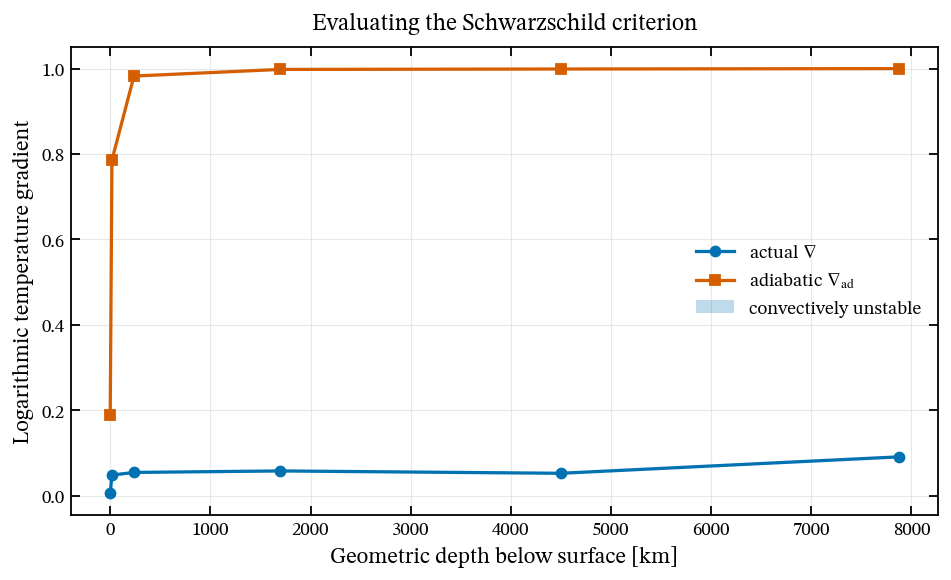

unstable layers: 0 of 6


In [21]:
convection = convection_checkpoint()
depth_km = convection.geometric_depth_below_surface_km
actual_gradient = convection.logarithmic_gradient
adiabatic_gradient = convection.adiabatic_gradient
unstable = actual_gradient > adiabatic_gradient

fig, ax = single_panel()
ax.plot(depth_km, actual_gradient, marker="o",
        label=r"actual $\nabla$")
ax.plot(depth_km, adiabatic_gradient, marker="s",
        label=r"adiabatic $\nabla_{\rm ad}$")
ax.fill_between(depth_km, adiabatic_gradient, actual_gradient,
                where=unstable, alpha=0.25,
                label="convectively unstable")
ax.set_xlabel("Geometric depth below surface [km]")
ax.set_ylabel("Logarithmic temperature gradient")
ax.set_title("Evaluating the Schwarzschild criterion")
add_quiet_grid(ax)
ax.legend()
plt.show()

print("unstable layers:", int(unstable.sum()), "of", unstable.size)


The two curves never cross on this fixture: \(\nabla\) stays below
\(\nabla_{\rm ad}\) at every depth, so the criterion reports a
stable column and the raw convective flux of §12.22 will be zero.
That is the correct answer here, not a missing feature — a
six-layer teaching slab sampled near the surface of a solar-like
star is not where convection dominates. Seeing the criterion
evaluate cleanly to *stable* is what makes the nonzero diagnostic
case later in the chapter interpretable.

### 12.20 The adiabatic gradient is a thermodynamic property

The criterion is only useful once \(\nabla_{\rm ad}\) is a number
we can compute. It follows from the first law alone. With no heat
exchanged, the work done by a unit mass of gas comes entirely out
of its internal energy, and for an ideal gas the adiabatic relation
\(PV^{\gamma}={\rm const}\) with \(\gamma=c_P/c_V\) rearranges into
\(T\,P^{(1-\gamma)/\gamma}={\rm const}\). Differentiating
logarithmically,

\[
\nabla_{\rm ad}
=\frac{\gamma-1}{\gamma}
=1-\frac{c_V}{c_P}.
\]

For a monatomic ideal gas \(\gamma=5/3\), so
\(\nabla_{\rm ad}=2/5=0.4\). That single number would be the whole
story if stellar gas were always a simple monatomic ideal gas.

It is not, and the reason connects directly to the perturbation
machinery of §§12.14–12.18. Where hydrogen is partially ionized,
heat added to the gas is partly spent unbinding electrons instead
of raising the temperature. That raises \(c_P\), which lowers
\(\nabla_{\rm ad}\) below \(0.4\) and makes convection *easier* to
trigger — which is precisely why the outer layers of cool stars
convect. This is why the implementation never hard-codes \(0.4\).
It recovers \(c_P\) and \(\nabla_{\rm ad}\) from the exact EOS
temperature and pressure derivatives we just built, so that
ionization physics enters the stability criterion automatically.

We also need a length. Hydrostatic balance from Chapter 1,
\(dP/dr=-\rho g\), gives \(d\ln P/dr=-\rho g/P\), so the distance
over which pressure falls by one factor of \(e\) is the **pressure
scale height**

\[
H_P=-\frac{dr}{d\ln P}=\frac{P}{\rho g}.
\]


### 12.21 What a moving parcel actually carries

A parcel that rises and stays hot eventually dissolves into its
surroundings and deposits its excess heat there. Mixing-length
theory makes that picture quantitative by assuming the parcel
survives one characteristic distance \(\ell=\alpha H_P\) before
mixing, with \(\alpha\) a dimensionless free parameter of order
unity.

Over that distance the parcel builds a temperature excess set by
how far the two gradients diverge:

\[
\frac{\Delta T}{T}=(\nabla-\nabla_{\rm ad})\,\frac{\ell}{H_P}.
\]

Being hotter at equal pressure, it is lighter by
\(\Delta\rho/\rho=-\Delta T/T\), so buoyancy accelerates it at
\(a=g\,\Delta T/T\). Letting it accelerate over \(\ell\) gives a
characteristic speed

\[
v\sim\sqrt{a\,\ell}=\sqrt{\frac{g\,\ell^{2}}{H_P}
(\nabla-\nabla_{\rm ad})}.
\]

Each gram carries an enthalpy excess \(c_P\Delta T\), and mass
conservation means an equal mass of cooler gas sinks to replace it.
The convective flux is therefore \(F_{\rm conv}\sim\rho v c_P\Delta T\):

\[
F_{\rm conv}
\sim
\rho\,c_P\,T\,
\frac{\ell}{H_P}
\left(\frac{g\,\ell^{2}}{H_P}\right)^{1/2}
(\nabla-\nabla_{\rm ad})^{3/2}.
\]

Two features matter more than the prefactor. The flux switches on
only above \(\nabla_{\rm ad}\), and it rises as the \(3/2\) power
of the excess — so convection is a stiff regulator. A slight
steepening past the threshold carries a great deal of flux, which
is why convective regions sit so close to adiabatic. The factors of
order unity differ between mixing-length conventions; the
implementation fixes one convention, and our job is to match it
exactly rather than to rederive it.

Notice that this expression needs exactly \(\rho\), \(c_P\), \(T\),
\(g\), \(H_P\), and \(\nabla_{\rm ad}\) — every one of which came
out of the perturbed EOS closures. The thermodynamics of the last
five sections was not a detour; it was the input list for
convection.


### 12.22 Convection has production and diagnostic branches

The implementation first computes the local raw result of the
previous section, then applies overshoot bookkeeping and a separate
top-layer suppression policy. These stages must remain visible
because “no returned convective flux” can mean either a stable
layer or a policy-suppressed surface value.

The finite-difference production fixture below is stable, so its
raw flux is zero. Its six layers also lie inside the standard
surface-suppression region. A deliberately steep diagnostic column
demonstrates another boundary: disabled-convection diagnostics may
still report a nonzero endpoint, but they are not a production
`ConvectionResult`.


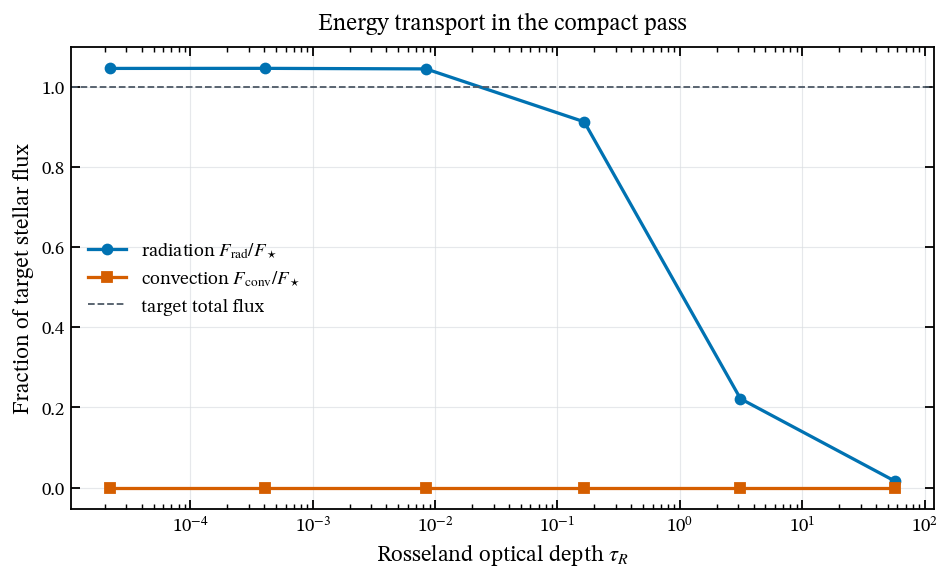

nabla / nabla_ad: [0.00626464 0.04893128 0.05510055 0.05856254 0.0530913  0.09148671] [0.18829882 0.7858002  0.98235573 0.99786346 0.99883115 0.99973279]
surface policy suppresses all six fixture layers: True
disabled diagnostic can remain nonzero: True


In [22]:
convection = convection_checkpoint()
target_flux = 5.6697e-5 * EFFECTIVE_TEMPERATURE ** 4
tau_R = finalization.rosseland_optical_depth

fig, ax = single_panel()
ax.semilogx(
    tau_R, physical_flux / target_flux,
    marker="o", label=r"radiation $F_{\rm rad}/F_\star$",
)
ax.semilogx(
    tau_R, convection.returned_convective_flux / target_flux,
    marker="s", label=r"convection $F_{\rm conv}/F_\star$",
)
ax.axhline(1.0, color="#4d5966", lw=1.0, ls="--",
           label="target total flux")
ax.set_xlabel(r"Rosseland optical depth $\tau_R$")
ax.set_ylabel("Fraction of target stellar flux")
ax.set_title("Energy transport in the compact pass")
add_quiet_grid(ax)
ax.legend()
plt.show()

print("nabla / nabla_ad:",
      convection.logarithmic_gradient,
      convection.adiabatic_gradient)
print("surface policy suppresses all six fixture layers:",
      convection.standard_six_layer_fixture_fully_suppressed)
print("disabled diagnostic can remain nonzero:",
      convection.disabled_can_be_nonzero)


### 12.23 Exact finalizer and opaque handoff

The finalizer now holds everything needed to diagnose one
atmospheric pass: Rosseland opacity and optical depth, radiation
pressure, updated lookup history, optional thermodynamic samples,
optional convection, and one temperature-correction result.

It intentionally does *not* apply that correction. Measuring the
imbalance and changing the atmosphere are separate operations.
That separation lets the next stage impose step limits, remap
every coupled column together, and test convergence before another
population/opacity pass begins. Because mode 3 aliases its
accumulators, the transfer object remains single-use.


In [23]:
exact_handoff = chapter11_finalization_checkpoint()
print("handoff types:", exact_handoff.finalization_type,
      "->", exact_handoff.correction_type)
print("layers / frequencies:",
      exact_handoff.depth_count, exact_handoff.frequency_count)
print("correction fields:",
      exact_handoff.correction_field_names)
print("finite / monotone m:",
      exact_handoff.correction_result_finite,
      exact_handoff.correction_column_mass_strictly_increasing)
print("Chapter 11 source retained:",
      exact_handoff.source_is_chapter11_cache)


handoff types: IterationFinalization -> TemperatureCorrectionResult
layers / frequencies: 80 30000
correction fields: ('temperature', 'flux_error_percent', 'flux_derivative', 'flux_temperature_derivative', 'lambda_temperature_derivative', 'surface_temperature_derivative', 'temperature_correction', 'flux_ratio', 'convective_flux', 'column_mass', 'column_mass_correction')
finite / monotone m: True True
Chapter 11 source retained: True


## 12.24 Chapter summary

1. One depth-major opacity state fans 30,000 ordered frequencies
   into nine float64 accumulator outputs.
2. Parallel work is isolated in contiguous private chunks; a fixed
   ascending reduction policy is bitwise repeatable.
3. Rosseland opacity, radiation energy, acceleration, pressure,
   heating, lambda response, and integrated \(H\) retain distinct
   units and meanings.
4. Mode 3 aliases and mutates accumulator state, updates the
   persistent Rosseland lookup, and is single-use.
5. Four EOS perturbations are one restore transaction. The exact
   charge-square and all-zero-energy restoration limitations are
   visible rather than repaired.
6. Convection consumes all eight finite-difference samples or none;
   raw flux, top suppression, and disabled diagnostics are
   separate branches.
7. The temperature-correction result is present but unopened. No
   corrected atmosphere exists yet.

The exact handoff now available is:

`OpacityState → TransferAccumulation → Rosseland/radiation
finalization → persistent lookup → optional convection →
IterationFinalization`

### Next: turn imbalance into a safe new atmosphere

The frequency field has collapsed into opacity, radiative support,
heating response, and a declared convective contribution. Those
columns diagnose what must change; they do not yet define a safe
updated structure. [Chapter 13](/reader.html?ch=13) opens the exact
correction result, remaps the complete state, carries only the
permitted history into the next pass, and decides when the
repeated orbit may stop.
